# ReGRID model analysis

### Locational marginal prices

Last update: 12 February, 2026

Dependency: model.py

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import geopandas as gpd
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os

In [ ]:
# Case setting
TERM = '1y' # Analysis term: 1y=Yearly
STEP = 6 # Timestep(h)
VER = 'v8' # Model version
YEAR = 2050 # Target year
BOUNDARY = 'japan' # Spatial boundary
NETWORK = '1741' # TSN:Transmission, '1741':Municipality
PATHWAY = 'C1' # Socioeconomic and emission pathway: C1:1.5C, C7:below 4C
POTENTIAL_AVAILABILITY = 100 # Uniform availability of renewable energy(%)
POTENTIAL_CASE = 'high' # Renewable energy potential assumptions ('base':HPA, 'low':PA+OECM, 'mid':Enhanced, 'high':FullProtect)
COST_CASE = 'moderate' # Cost assumption

TECH_CASE = 'ccs-biomass'
if TECH_CASE == 'ccs-biomass':
    CCS_AVAILAVILITY = 2 # 0:Not available, 1:Unlimited, 2:Only domestic
    NUCLEAR_AVAILABILITY = 2 # 0:Not available, 1:Available, 2:No new installation
    BIOMASS_CAP = 0.1 # Availability of technical potential
else:
    CCS_AVAILAVILITY = 1 # 0:Not available, 1:Unlimited, 2:Only domestic
    NUCLEAR_AVAILABILITY = 1 # 0:Not available, 1:Available, 2:No new installation
    BIOMASS_CAP = 1 # Availability of technical potential

In [13]:
# Initialize a model
def get_model_name(ver=VER, year=YEAR, pathway=PATHWAY, term=TERM, step=STEP, boundary=BOUNDARY, network=NETWORK, nuclear=NUCLEAR_AVAILABILITY, potential=POTENTIAL_AVAILABILITY, potential_case=POTENTIAL_CASE, cost_case=COST_CASE, tech_case=TECH_CASE):
    return f"ReGRID2_{ver}_{year}_{pathway}_{term}_{step}_{boundary}_{network}_n{nuclear}_p{potential}_{potential_case}_{cost_case}_{tech_case}"

model_name = get_model_name()
print(model_name)

ReGRID2_v8_2050_C1_1y_6_japan_1741_n2_p100_high_moderate_ccs-biomass


In [14]:
# Data for analysis

CASES = ['base','low','mid','high']
CASE_NAME = {'low':'PA+OECM', 'mid':'Enhanced', 'high':'FullProtect', 'sea':'MarineProtect', 'land':'LandProtect', 'base':'HPA'}

# Result
dual = pd.read_csv('output/%s/dual_%s.csv' % (model_name,model_name), index_col=0, dtype={'region':str, 'time':str})
dual = dual.replace('_', '', regex=True) #Remove blank
dual = dual.replace(' ', '', regex=True) #Remove blank

# Technology dataset
P = pd.read_csv(f'input/technology/technology_{PATHWAY}.csv', index_col=0)
P = P[P['year'] == int(YEAR)]

# Region list
region_list = pd.read_csv('input/region.csv', index_col='code', dtype={'code':str, 'DSN':str})
REGION = region_list.index.to_list() # All nodes

# JPY -> USD
USD = 107 # TTM in 2020

In [15]:
# Chart paramter
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['xtick.major.size'] = 2.5
plt.rcParams['ytick.major.size'] = 2.5
plt.rcParams['font.size'] = 6
plt.rcParams['xtick.labelsize'] = 6
plt.rcParams['ytick.labelsize'] = 6
plt.rcParams['axes.linewidth'] = 0

MAX_WIDTH = 180 / 25.4 # inch in 180mm

In [ ]:
# Draw map

def map_plot(map_data, map_label, cmap, map_min, map_max, map_title):

    # Boundary
    # National boundary
    japan_shapes = list(gpd.read_file("input/analysis/boundary/Japan.gpkg").geometry)
    municipal_shapes = list(gpd.read_file("input/analysis/boundary/1741municipalities.gpkg").geometry)

    # Colormap
    if map_max == "max":
        color_max = map_data.max()
    else:
        color_max = map_max

    if map_min == "min":
        color_min = map_data.min()
    else:
        color_min = map_min

    norm = mcolors.Normalize(vmin=color_min, vmax=color_max)

    # Map
    fig = plt.figure(figsize=(MAX_WIDTH*0.5, MAX_WIDTH*0.5*1.25), dpi=3000)
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Regional polygon
    for n, city in enumerate(municipal_shapes):
        value = min(map_data.iloc[n], color_max)
        value = max(value, color_min)
        polygon_color = cmap(norm(value)) if value > 0 else "#eee"
        ax.add_geometries(city, ccrs.PlateCarree(), edgecolor=(0.5,0.5,0.5,1), facecolor=polygon_color, linewidth = 0.0, zorder=1)

    area_cood = [126.6, 147.0, 25.6, 45.9]
    ax.set_extent(area_cood, crs=ccrs.PlateCarree())
    ax.add_geometries(japan_shapes, ccrs.PlateCarree(), edgecolor=(0.1,0.1,0.1,1), facecolor=(0,0,0,0), linewidth = 0.05, zorder=2)

    # Gridline
    gl = ax.gridlines(draw_labels=True, linewidth=0.1, color='gray', alpha=0.6, linestyle='--')
    gl.top_labels = True
    gl.right_labels = False
    gl.bottom_labels = False
    gl.left_labels = True
    gl.xlabel_style = {'fontsize': 5, 'color': "gray"}
    gl.ylabel_style = {'fontsize': 5, 'color': "gray"}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xpadding = 1
    gl.ypadding = 1
    
    # Draw
    heat_map = ax.imshow([[color_min],[color_max]], cmap=cmap, norm=norm)
    cbar = fig.colorbar(heat_map, shrink=0.83, aspect=40, pad=0.02, orientation='horizontal')
    cbar.set_label(map_label, fontsize=5, labelpad=3)
    cbar.ax.tick_params(labelsize=5, pad=1)
    cbar.ax.set_xscale('linear')
    
    plt.axis('off')
    if map_title is not None:
        plt.savefig("output/%s/%s.png" % (model_name,map_title), bbox_inches='tight', pad_inches=0, transparent=False, dpi=1200)
        # plt.savefig("output/%s/%s.pdf" % (model_name,map_title), bbox_inches='tight', pad_inches=0, dpi=300)
    plt.show()
    plt.clf()

In [17]:
# Locational marginal price

price = dual[(dual.id == 'ele')][['region','time','value']].astype({'region':int,'time':int}).set_index(['region','time'])['value'] * 1000 # million JPY/MWh -> JPY/kWh
price = price / USD * 1000 # JPY/kWh -> USD/MWh

price_region = price.groupby(['region'], as_index=True).mean().sort_index()
price_region.to_csv('output/%s/price_region_%s.csv' % (model_name,model_name))

print(price_region.mean())
print(price_region.median())

# map
map_plot(price_region, 'Locational marginal price (USD MWh$^{-1}$)', cm.viridis, price_region.quantile(0.025), price_region.quantile(0.975), f'map_price_{model_name}_95')

167.78348165985005
171.79319273642562


<Figure size 640x480 with 0 Axes>

base     75.113428
low      77.558813
mid      83.215247
high    171.793193
dtype: float64


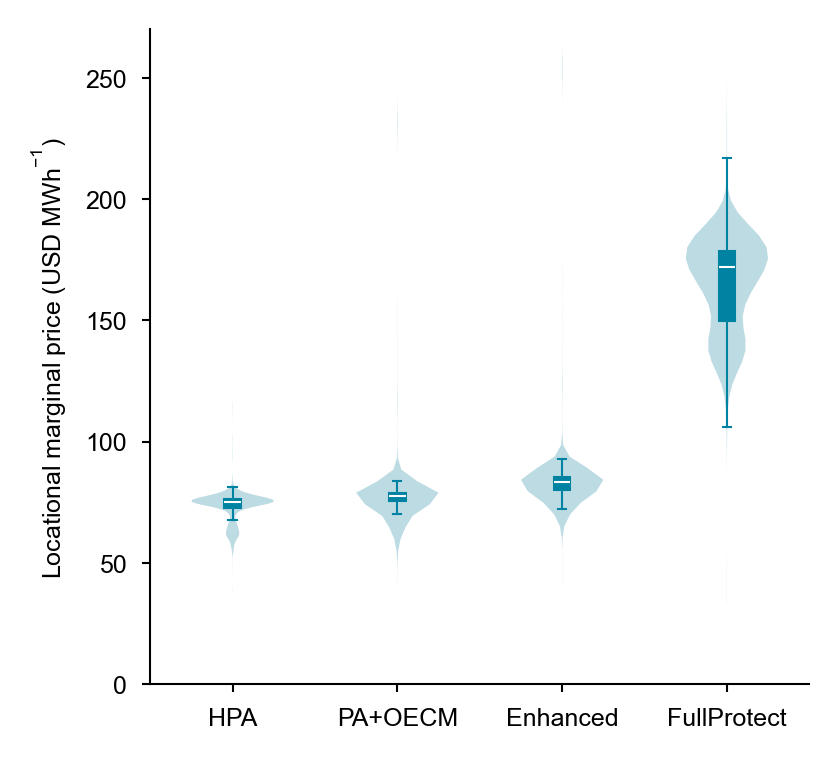

In [ ]:
# Box plot

output_path = 'output/analysis'
tech_case = 'ccs-biomass'
year = 2050

# Chart paramter
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['ytick.major.size'] = 2
plt.rcParams['axes.linewidth'] = 0.5


fig, ax = plt.subplots(1, 1, figsize=[MAX_WIDTH*0.4,MAX_WIDTH*0.4], dpi=300)
    
df_price = pd.DataFrame()
box_color = "#0082A3"
violin_color = "#5CA7BA"

for case in CASES:
    case_name = get_model_name(potential_case=case, tech_case=tech_case, year=year, nuclear=2)
    if os.path.isfile(f'output/{case_name}/price_region_{case_name}.csv'):
        df_price[case] = pd.read_csv(f'output/{case_name}/price_region_{case_name}.csv', index_col=0)
    else:
        print("No data:", case_name)

ax.boxplot(df_price, positions=[0,1,2,3], widths=0.1, patch_artist=True,
            boxprops=dict(facecolor=box_color, color=box_color, linewidth=0.5),
            whiskerprops=dict(color=box_color, linewidth=0.5),
            capprops=dict(color=box_color, linewidth=0.5),
            medianprops=dict(color='#fff', linewidth=0.5),
            flierprops=dict(marker='o', markersize=0))
violin = ax.violinplot(df_price, positions=[0,1,2,3], widths=0.5, bw_method="scott", showmeans=False, showextrema=False, showmedians=False)

for body in violin['bodies']:
    body.set_color(violin_color)
    body.set_edgecolor("none")
    body.set_alpha(0.4)

ax.set_ylim(0, 270)
ax.set_xticklabels([CASE_NAME[case] for case in CASES])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Locational marginal price (USD MWh$^{-1}$)')

print(df_price.median())

plt.savefig(f"{output_path}/LMP_{tech_case}_{year}.png", bbox_inches='tight', pad_inches=0, transparent=False, dpi=1200)
plt.savefig(f"{output_path}/LMP_{tech_case}_{year}.pdf", bbox_inches='tight', pad_inches=0, transparent=False)
plt.show()